In [1]:

# Import necessary libraries
import numpy as np
import pickle
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.stats import entropy
import pandas as pd
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")
print(f"NumPy version: {np.__version__}")
print(f"Available files:")
import os
for f in os.listdir('.'):
 if f.endswith('.pkl'):
 print(f" - {f}")


Libraries imported successfully
NumPy version: 1.26.4
Available files:
 - detailed_results_N1e6.pkl
 - omega_values_N1e6.pkl
 - f_canon_rand_primes_N1e7.pkl


In [2]:

# Load the pre-computed omega values (N=10^6) to understand the structure
with open('omega_values_N1e6.pkl', 'rb') as f:
 omega_values_1e6 = pickle.load(f)

print(f"Omega values array shape: {omega_values_1e6.shape}")
print(f"First 20 values (0-indexed, so omega_values[i] = Ω(i+1)):")
print(omega_values_1e6[:20])
print(f"\nMax omega value in range: {omega_values_1e6.max()}")


Omega values array shape: (1000000,)
First 20 values (0-indexed, so omega_values[i] = Ω(i+1)):
[0 1 1 2 1 2 1 3 2 2 1 3 1 2 2 4 1 3 1 3]

Max omega value in range: 19


In [3]:

# Load the N=10^6 detailed results to understand structure
with open('detailed_results_N1e6.pkl', 'rb') as f:
 results_1e6 = pickle.load(f)

print("Keys in detailed_results_N1e6.pkl:")
for key in results_1e6.keys():
 print(f" - {key}")
 if isinstance(results_1e6[key], dict):
 print(f" Subkeys: {list(results_1e6[key].keys())}")


Keys in detailed_results_N1e6.pkl:
 - zeta
 Subkeys: ['magnitudes', 'peak_t', 'peak_heights', 'peak_indices', 'r_values', 'mean_r', 'std_r', 'median_r']
 - f_rand
 Subkeys: ['magnitudes', 'peak_t', 'peak_heights', 'peak_indices', 'r_values', 'mean_r', 'std_r', 'median_r']
 - L_mobius
 Subkeys: ['magnitudes', 'peak_t', 'peak_heights', 'peak_indices', 'r_values', 'mean_r', 'std_r', 'median_r']


In [4]:

# Fix: use 'a_p' instead of 'coefficients'
print(f"First 10 coefficients (a_p): {f_canon_data['a_p'][:10]}")
print(f"\nSeed: {f_canon_data['seed']}")
print(f"Max N: {f_canon_data['max_n']}")
print(f"Generation method: {f_canon_data['generation_method']}")
print(f"Formula: {f_canon_data['formula']}")


First 10 coefficients (a_p): [-0.70506063+0.70914702j 0.95243384-0.30474544j -0.11289421-0.99360701j
 -0.81394263-0.58094525j 0.55677833+0.83066112j 0.55690421+0.83057673j
 0.93414157+0.35690268j 0.66683703-0.74520358j -0.80487925-0.59343861j
 -0.26040125-0.96550049j]

Seed: 42
Max N: 10000000
Generation method: uniform on complex unit circle
Formula: a_p = exp(i*theta), theta ~ Uniform[0, 2π)


In [5]:

# Analysis Plan
print("="*80)
print("ANALYSIS PLAN: POWER REDISTRIBUTION ACROSS N=10^5 AND N=10^6")
print("="*80)
print()
print("OBJECTIVE:")
print("Test whether the power redistribution mechanism observed in the zeta function")
print("is a general feature of multiplicative functions by analyzing L(s,μ) and")
print("f_canon_rand at N=10^5 and N=10^6.")
print()
print("ANALYSIS STEPS:")
print()
print("Step 1: Generate N=10^5 data")
print(" 1a. Compute omega values for n=1 to N=10^5")
print(" 1b. Generate Möbius coefficients μ(n) for n=1 to N=10^5")
print(" 1c. Generate f_canon_rand coefficients a(n) for n=1 to N=10^5")
print(" 1d. Evaluate both functions on grid t ∈ [10^5, 2·10^5] with ~2000 points")
print(" 1e. Find top 50 peaks for each function using scipy.signal.find_peaks")
print()
print("Step 2: Load N=10^6 data")
print(" 2a. Load peak locations for L_mobius and f_rand from detailed_results_N1e6.pkl")
print(" 2b. Verify we have 50 peaks for each function")
print()
print("Step 3: ω-class decomposition at peaks")
print(" For each function (L_mobius, f_canon_rand) and scale (N=10^5, N=10^6):")
print(" 3a. At each peak t_peak, compute S_k = Σ_{Ω(n)=k} a_n/n^(1/2+it)")
print(" 3b. Compute power contributions P_k = |S_k|^2 for k=1 to 10")
print(" 3c. Calculate Shannon entropy H = -Σ (P_k/Σ P_j) log(P_k/Σ P_j)")
print(" 3d. Calculate variance contribution: Var(P_k)/Var(Den) where Den = Σ P_k")
print()
print("Step 4: Statistical comparison")
print(" 4a. For each function, compute mean and std of entropy H at N=10^5 and N=10^6")
print(" 4b. Test if mean entropy increases (H_N=10^6 > H_N=10^5)")
print(" 4c. Compute mean variance fraction for each k=1..10 at both scales")
print(" 4d. Test if variance shifts to higher k (k≥4) from N=10^5 to N=10^6")
print()
print("Step 5: Visualization and reporting")
print(" 5a. Create comparison plots showing variance contribution by k")
print(" 5b. Report quantitative evidence: entropy means, variance fractions, effect sizes")
print()
print("STATISTICAL METHODS:")
print(" - Shannon entropy for power distribution quantification")
print(" - Variance decomposition to track contribution by ω-class")
print(" - Effect size comparison (difference in means relative to pooled std)")
print()
print("COMPUTATIONAL NOTES:")
print(" - Use Kahan compensated summation for all Dirichlet sums")
print(" - Grid density: 2000 points for both N=10^5 and N=10^6")
print(" - Peak finding: scipy.signal.find_peaks with appropriate prominence")
print()
print("="*80)


ANALYSIS PLAN: POWER REDISTRIBUTION ACROSS N=10^5 AND N=10^6

OBJECTIVE:
Test whether the power redistribution mechanism observed in the zeta function
is a general feature of multiplicative functions by analyzing L(s,μ) and
f_canon_rand at N=10^5 and N=10^6.

ANALYSIS STEPS:

Step 1: Generate N=10^5 data
 1a. Compute omega values for n=1 to N=10^5
 1b. Generate Möbius coefficients μ(n) for n=1 to N=10^5
 1c. Generate f_canon_rand coefficients a(n) for n=1 to N=10^5
 1d. Evaluate both functions on grid t ∈ [10^5, 2·10^5] with ~2000 points
 1e. Find top 50 peaks for each function using scipy.signal.find_peaks

Step 2: Load N=10^6 data
 2a. Load peak locations for L_mobius and f_rand from detailed_results_N1e6.pkl
 2b. Verify we have 50 peaks for each function

Step 3: ω-class decomposition at peaks
 For each function (L_mobius, f_canon_rand) and scale (N=10^5, N=10^6):
 3a. At each peak t_peak, compute S_k = Σ_{Ω(n)=k} a_n/n^(1/2+it)
 3b. Compute power contributions P_k = |S_k|^2 for k=1

In [6]:

# Step 1a: Compute omega values for N=10^5
# Omega(n) = number of prime factors with multiplicity
def compute_omega_values(N):
 """Compute Ω(n) for n=1 to N using sieve-like approach"""
 omega = np.zeros(N, dtype=np.int32)
 
 # Sieve: for each prime p, add 1 to omega[p-1], omega[2p-1], etc.
 for n in range(2, N+1):
 if omega[n-1] == 0: # n is prime
 # Mark all multiples of n
 for m in range(n, N+1, n):
 temp = m
 while temp % n == 0:
 omega[m-1] += 1
 temp //= n
 
 return omega

print("Computing Ω(n) values for N=10^5...")
N_1e5 = 100000
omega_values_1e5 = compute_omega_values(N_1e5)

print(f"First 20 omega values: {omega_values_1e5[:20]}")
print(f"Max omega value: {omega_values_1e5.max()}")
print(f"Shape: {omega_values_1e5.shape}")


Computing Ω(n) values for N=10^5...


First 20 omega values: [0 1 1 2 1 2 1 3 2 2 1 3 1 2 2 4 1 3 1 3]
Max omega value: 16
Shape: (100000,)


In [7]:

# Step 1b: Generate Möbius coefficients μ(n) for n=1 to N=10^5
def mobius(N):
 """Compute Möbius function μ(n) for n=1 to N"""
 mu = np.ones(N, dtype=np.int8)
 is_prime = np.ones(N, dtype=bool)
 is_prime[0] = False # 1 is not prime
 
 for i in range(2, N+1):
 if is_prime[i-1]:
 # Mark multiples of i
 for j in range(i, N+1, i):
 is_prime[j-1] = False if j > i else is_prime[j-1]
 mu[j-1] *= -1
 
 # Mark multiples of i^2 as 0
 if i * i <= N:
 for j in range(i*i, N+1, i*i):
 mu[j-1] = 0
 
 return mu

print("Computing Möbius function μ(n) for N=10^5...")
mobius_1e5 = mobius(N_1e5)

print(f"First 30 Möbius values: {mobius_1e5[:30]}")
print(f"Number of μ(n)=1: {np.sum(mobius_1e5 == 1)}")
print(f"Number of μ(n)=-1: {np.sum(mobius_1e5 == -1)}")
print(f"Number of μ(n)=0: {np.sum(mobius_1e5 == 0)}")


Computing Möbius function μ(n) for N=10^5...


First 30 Möbius values: [ 1 -1 -1 0 -1 1 -1 0 0 1 -1 0 -1 1 1 0 -1 0 -1 0 1 1 -1 0
 0 1 0 0 -1 -1]
Number of μ(n)=1: 30373
Number of μ(n)=-1: 30421
Number of μ(n)=0: 39206


In [8]:

# Step 1c: Generate f_canon_rand coefficients a(n) for n=1 to N=10^5
def generate_f_canon_rand_coefficients(N, prime_coeff_dict):
 """
 Generate completely multiplicative random function coefficients.
 a(n) = ∏_{p^k || n} a_p^k where a_p are the canonical random prime coefficients
 """
 a = np.ones(N, dtype=np.complex128)
 
 # Get all primes up to N
 primes_up_to_N = [p for p in prime_coeff_dict.keys() if p <= N]
 
 for p in primes_up_to_N:
 a_p = prime_coeff_dict[p]
 # For each power of p
 power = 1
 p_power = p
 while p_power <= N:
 # a(p^power) = a_p^power
 a_p_power = a_p ** power
 # Apply to all multiples of p^power
 for m in range(p_power, N+1, p_power):
 # Check if p^power exactly divides m
 temp = m
 count = 0
 while temp % p == 0:
 temp //= p
 count += 1
 if count >= power:
 a[m-1] = a_p_power
 # For higher powers, multiply by additional factors
 if count > power:
 a[m-1] *= a_p ** (count - power)
 
 power += 1
 p_power *= p
 
 return a

print("Generating f_canon_rand coefficients for N=10^5...")
# This is computationally intensive, so let's use a more efficient approach


Generating f_canon_rand coefficients for N=10^5...


In [9]:

# More efficient implementation using prime factorization
def generate_f_canon_rand_efficient(N, prime_coeff_dict):
 """
 Generate completely multiplicative random function coefficients efficiently.
 For completely multiplicative: a(mn) = a(m)a(n) for coprime m,n
 So a(n) = ∏_{p|n} a_p^{v_p(n)} where v_p(n) is the exponent of p in n's factorization
 """
 a = np.ones(N, dtype=np.complex128)
 
 # Get sorted primes
 primes = sorted([p for p in prime_coeff_dict.keys() if p <= N])
 
 # For each prime, multiply a[multiples of p] by appropriate power of a_p
 for p in primes:
 a_p = prime_coeff_dict[p]
 
 # For each multiple of p, determine the power and multiply
 for n in range(p, N+1, p):
 temp = n
 exponent = 0
 while temp % p == 0:
 temp //= p
 exponent += 1
 a[n-1] *= a_p ** exponent
 
 return a

print("Generating f_canon_rand coefficients for N=10^5 (efficient method)...")
f_canon_rand_1e5 = generate_f_canon_rand_efficient(N_1e5, f_canon_data['prime_coeff_dict'])

print(f"First 10 coefficients: {f_canon_rand_1e5[:10]}")
print(f"Coefficient at n=2: {f_canon_rand_1e5[1]} (should be a_2)")
print(f"a_2 from dict: {f_canon_data['prime_coeff_dict'][2]}")
print(f"Coefficient at n=4: {f_canon_rand_1e5[3]} (should be a_2^2)")
print(f"a_2^2: {f_canon_data['prime_coeff_dict'][2]**2}")
print(f"\nAll coefficients on unit circle (verification):")
print(f"Mean |a(n)|: {np.mean(np.abs(f_canon_rand_1e5)):.6f}")
print(f"Std |a(n)|: {np.std(np.abs(f_canon_rand_1e5)):.6e}")


Generating f_canon_rand coefficients for N=10^5 (efficient method)...
First 10 coefficients: [ 1. +0.j -0.70506063+0.70914702j 0.95243384-0.30474544j
 -0.005779 -0.9999833j -0.11289421-0.99360701j -0.45541428+0.89027964j
 -0.81394263-0.58094525j 0.71320973+0.7009507j 0.81426043-0.58049974j
 0.78421072+0.6204946j ]
Coefficient at n=2: (-0.7050606339757902+0.7091470245426238j) (should be a_2)
a_2 from dict: (-0.7050606339757902+0.7091470245426238j)
Coefficient at n=4: (-0.005779004835313406-0.9999833014121352j) (should be a_2^2)
a_2^2: (-0.005779004835313406-0.9999833014121352j)

All coefficients on unit circle (verification):
Mean |a(n)|: 1.000000
Std |a(n)|: 1.302458e-16


In [10]:

# Step 1d: Kahan compensated summation function
def kahan_sum_dirichlet(coefficients, omega_values, t_val, N, k_max=10):
 """
 Compute Dirichlet sum with ω-class decomposition using Kahan summation.
 
 Returns:
 S_k: array of complex sums for each ω-class k=0 to k_max
 """
 S_k = np.zeros(k_max + 1, dtype=np.complex128)
 c_k = np.zeros(k_max + 1, dtype=np.complex128) # Compensation terms
 
 for n in range(1, N+1):
 omega_n = omega_values[n-1]
 if omega_n <= k_max:
 term = coefficients[n-1] / (n ** (0.5 + 1j * t_val))
 # Kahan summation
 y = term - c_k[omega_n]
 temp = S_k[omega_n] + y
 c_k[omega_n] = (temp - S_k[omega_n]) - y
 S_k[omega_n] = temp
 
 return S_k

# Test on a single point
print("Testing Kahan summation for Möbius function...")
t_test = 100000.0
S_k_test = kahan_sum_dirichlet(mobius_1e5, omega_values_1e5, t_test, N_1e5, k_max=10)
print(f"S_k at t={t_test}:")
for k in range(11):
 print(f" S_{k} = {S_k_test[k]:.6f}, |S_{k}|² = {np.abs(S_k_test[k])**2:.6f}")


Testing Kahan summation for Möbius function...


S_k at t=100000.0:
 S_0 = 1.000000+0.000000j, |S_0|² = 1.000000
 S_1 = -1.593744-1.545918j, |S_1|² = 4.929882
 S_2 = 0.094869+2.433919j, |S_2|² = 5.932961
 S_3 = 0.842118-1.144573j, |S_3|² = 2.019212
 S_4 = -0.502441+0.216216j, |S_4|² = 0.299196
 S_5 = 0.052104-0.039331j, |S_5|² = 0.004262
 S_6 = 0.014494+0.008622j, |S_6|² = 0.000284
 S_7 = 0.000000+0.000000j, |S_7|² = 0.000000
 S_8 = 0.000000+0.000000j, |S_8|² = 0.000000
 S_9 = 0.000000+0.000000j, |S_9|² = 0.000000
 S_10 = 0.000000+0.000000j, |S_10|² = 0.000000


In [11]:

# Step 1d continued: Evaluate both functions on t-grid
def evaluate_dirichlet_grid(coefficients, omega_values, t_grid, N, k_max=10):
 """Evaluate Dirichlet polynomial on a grid of t values"""
 n_points = len(t_grid)
 magnitudes = np.zeros(n_points)
 
 print(f"Evaluating {n_points} points...")
 for i, t in enumerate(t_grid):
 if i % 200 == 0:
 print(f" Progress: {i}/{n_points}")
 
 S_k = kahan_sum_dirichlet(coefficients, omega_values, t, N, k_max=k_max)
 D_total = np.sum(S_k)
 magnitudes[i] = np.abs(D_total)
 
 return magnitudes

# Create t-grid for N=10^5
print("Creating t-grid for N=10^5...")
n_grid_points = 2000
t_min_1e5 = N_1e5
t_max_1e5 = 2 * N_1e5
t_grid_1e5 = np.linspace(t_min_1e5, t_max_1e5, n_grid_points)
print(f"t-grid: [{t_grid_1e5[0]:.1f}, {t_grid_1e5[-1]:.1f}] with {n_grid_points} points")


Creating t-grid for N=10^5...
t-grid: [100000.0, 200000.0] with 2000 points


In [12]:

# Evaluate Möbius function on grid
print("="*80)
print("Evaluating L(s,μ) on t-grid for N=10^5...")
print("="*80)
magnitudes_mobius_1e5 = evaluate_dirichlet_grid(mobius_1e5, omega_values_1e5, 
 t_grid_1e5, N_1e5, k_max=10)

print(f"\nMagnitude statistics:")
print(f" Mean: {np.mean(magnitudes_mobius_1e5):.4f}")
print(f" Std: {np.std(magnitudes_mobius_1e5):.4f}")
print(f" Max: {np.max(magnitudes_mobius_1e5):.4f}")
print(f" Min: {np.min(magnitudes_mobius_1e5):.4f}")


Evaluating L(s,μ) on t-grid for N=10^5...
Evaluating 2000 points...
 Progress: 0/2000


 Progress: 200/2000


 Progress: 400/2000


 Progress: 600/2000


 Progress: 800/2000


...

 Progress: 1200/2000


 Progress: 1400/2000


 Progress: 1600/2000


 Progress: 1800/2000



Magnitude statistics:
 Mean: 2.0067
 Std: 1.9123
 Max: 18.0127
 Min: 0.0223


In [13]:

# Evaluate f_canon_rand on grid
print("="*80)
print("Evaluating f_canon_rand on t-grid for N=10^5...")
print("="*80)
magnitudes_frand_1e5 = evaluate_dirichlet_grid(f_canon_rand_1e5, omega_values_1e5, 
 t_grid_1e5, N_1e5, k_max=10)

print(f"\nMagnitude statistics:")
print(f" Mean: {np.mean(magnitudes_frand_1e5):.4f}")
print(f" Std: {np.std(magnitudes_frand_1e5):.4f}")
print(f" Max: {np.max(magnitudes_frand_1e5):.4f}")
print(f" Min: {np.min(magnitudes_frand_1e5):.4f}")


Evaluating f_canon_rand on t-grid for N=10^5...
Evaluating 2000 points...
 Progress: 0/2000


 Progress: 200/2000


 Progress: 400/2000


 Progress: 600/2000


 Progress: 800/2000


...

 Progress: 1200/2000


 Progress: 1400/2000


 Progress: 1600/2000


 Progress: 1800/2000



Magnitude statistics:
 Mean: 2.1730
 Std: 2.6393
 Max: 32.9215
 Min: 0.0075


In [14]:

# Step 1e: Find top 50 peaks for each function
print("="*80)
print("Finding peaks for L(s,μ) at N=10^5...")
print("="*80)

# Find peaks with prominence requirement
peaks_mobius_1e5, properties_mobius = find_peaks(magnitudes_mobius_1e5, 
 prominence=1.0)

print(f"Total peaks found: {len(peaks_mobius_1e5)}")
print(f"Top peak magnitude: {magnitudes_mobius_1e5[peaks_mobius_1e5[0]]:.4f}")

# Sort by height and take top 50
peak_heights_mobius = magnitudes_mobius_1e5[peaks_mobius_1e5]
sorted_indices_mobius = np.argsort(peak_heights_mobius)[::-1]
top50_peaks_mobius_1e5 = peaks_mobius_1e5[sorted_indices_mobius[:50]]
top50_t_mobius_1e5 = t_grid_1e5[top50_peaks_mobius_1e5]
top50_heights_mobius_1e5 = magnitudes_mobius_1e5[top50_peaks_mobius_1e5]

print(f"\nTop 10 peaks for L(s,μ):")
for i in range(10):
 print(f" Peak {i+1}: t = {top50_t_mobius_1e5[i]:.2f}, height = {top50_heights_mobius_1e5[i]:.4f}")


Finding peaks for L(s,μ) at N=10^5...
Total peaks found: 558
Top peak magnitude: 2.9217

Top 10 peaks for L(s,μ):
 Peak 1: t = 135867.93, height = 18.0127
 Peak 2: t = 191795.90, height = 15.1282
 Peak 3: t = 152826.41, height = 14.6796
 Peak 4: t = 146923.46, height = 13.6725
 Peak 5: t = 182141.07, height = 12.8155
 Peak 6: t = 189394.70, height = 11.8399
 Peak 7: t = 179939.97, height = 11.0294
 Peak 8: t = 188044.02, height = 10.9404
 Peak 9: t = 178589.29, height = 10.8783
 Peak 10: t = 118109.05, height = 10.5553


In [15]:

# Find peaks for f_canon_rand
print("="*80)
print("Finding peaks for f_canon_rand at N=10^5...")
print("="*80)

peaks_frand_1e5, properties_frand = find_peaks(magnitudes_frand_1e5, 
 prominence=1.0)

print(f"Total peaks found: {len(peaks_frand_1e5)}")

# Sort by height and take top 50
peak_heights_frand = magnitudes_frand_1e5[peaks_frand_1e5]
sorted_indices_frand = np.argsort(peak_heights_frand)[::-1]
top50_peaks_frand_1e5 = peaks_frand_1e5[sorted_indices_frand[:50]]
top50_t_frand_1e5 = t_grid_1e5[top50_peaks_frand_1e5]
top50_heights_frand_1e5 = magnitudes_frand_1e5[top50_peaks_frand_1e5]

print(f"\nTop 10 peaks for f_canon_rand:")
for i in range(10):
 print(f" Peak {i+1}: t = {top50_t_frand_1e5[i]:.2f}, height = {top50_heights_frand_1e5[i]:.4f}")


Finding peaks for f_canon_rand at N=10^5...
Total peaks found: 551

Top 10 peaks for f_canon_rand:
 Peak 1: t = 121560.78, height = 32.9215
 Peak 2: t = 183391.70, height = 29.1873
 Peak 3: t = 100350.18, height = 25.3674
 Peak 4: t = 179639.82, height = 19.4390
 Peak 5: t = 137968.98, height = 18.9178
 Peak 6: t = 179439.72, height = 18.6606
 Peak 7: t = 129664.83, height = 18.2889
 Peak 8: t = 171335.67, height = 17.6726
 Peak 9: t = 123711.86, height = 16.8279
 Peak 10: t = 169984.99, height = 16.5242


In [16]:

# Step 2: Load N=10^6 peak data
print("="*80)
print("Loading N=10^6 peak data from detailed_results_N1e6.pkl...")
print("="*80)

# Extract peak t-values for Möbius
top50_t_mobius_1e6 = results_1e6['L_mobius']['peak_t']
top50_heights_mobius_1e6 = results_1e6['L_mobius']['peak_heights']

print(f"\nL(s,μ) at N=10^6:")
print(f" Number of peaks: {len(top50_t_mobius_1e6)}")
print(f" Top 5 peaks:")
for i in range(5):
 print(f" Peak {i+1}: t = {top50_t_mobius_1e6[i]:.2f}, height = {top50_heights_mobius_1e6[i]:.4f}")

# Extract peak t-values for f_rand (canonical random)
top50_t_frand_1e6 = results_1e6['f_rand']['peak_t']
top50_heights_frand_1e6 = results_1e6['f_rand']['peak_heights']

print(f"\nf_canon_rand at N=10^6:")
print(f" Number of peaks: {len(top50_t_frand_1e6)}")
print(f" Top 5 peaks:")
for i in range(5):
 print(f" Peak {i+1}: t = {top50_t_frand_1e6[i]:.2f}, height = {top50_heights_frand_1e6[i]:.4f}")


Loading N=10^6 peak data from detailed_results_N1e6.pkl...

L(s,μ) at N=10^6:
 Number of peaks: 50
 Top 5 peaks:
 Peak 1: t = 1518000.00, height = 18.5281
 Peak 2: t = 1990000.00, height = 17.0860
 Peak 3: t = 1745000.00, height = 16.9884
 Peak 4: t = 1896000.00, height = 16.7073
 Peak 5: t = 1544000.00, height = 15.3680

f_canon_rand at N=10^6:
 Number of peaks: 50
 Top 5 peaks:
 Peak 1: t = 1310000.00, height = 28.0831
 Peak 2: t = 1244000.00, height = 27.8153
 Peak 3: t = 1974000.00, height = 21.2976
 Peak 4: t = 1112000.00, height = 20.8469
 Peak 5: t = 1842000.00, height = 18.5859


In [17]:

# For N=10^6, we need the coefficients. Let's generate them now.
print("="*80)
print("Generating coefficients for N=10^6...")
print("="*80)

N_1e6 = 1000000

# We already have omega values for 10^6
print(f"\nUsing pre-computed omega values (shape: {omega_values_1e6.shape})")

# Generate Möbius coefficients for N=10^6
print("\nGenerating Möbius function μ(n) for N=10^6...")
mobius_1e6 = mobius(N_1e6)
print(f" μ(n)=1: {np.sum(mobius_1e6 == 1)}")
print(f" μ(n)=-1: {np.sum(mobius_1e6 == -1)}")
print(f" μ(n)=0: {np.sum(mobius_1e6 == 0)}")


Generating coefficients for N=10^6...

Using pre-computed omega values (shape: (1000000,))

Generating Möbius function μ(n) for N=10^6...


 μ(n)=1: 304069
 μ(n)=-1: 303857
 μ(n)=0: 392074


In [18]:

# Generate f_canon_rand coefficients for N=10^6
print("Generating f_canon_rand coefficients for N=10^6...")
f_canon_rand_1e6 = generate_f_canon_rand_efficient(N_1e6, f_canon_data['prime_coeff_dict'])

print(f"Mean |a(n)|: {np.mean(np.abs(f_canon_rand_1e6)):.10f}")
print(f"Std |a(n)|: {np.std(np.abs(f_canon_rand_1e6)):.2e}")
print(f"First 10 coefficients: {f_canon_rand_1e6[:10]}")


Generating f_canon_rand coefficients for N=10^6...


Mean |a(n)|: 1.0000000000
Std |a(n)|: 1.32e-16
First 10 coefficients: [ 1. +0.j -0.70506063+0.70914702j 0.95243384-0.30474544j
 -0.005779 -0.9999833j -0.11289421-0.99360701j -0.45541428+0.89027964j
 -0.81394263-0.58094525j 0.71320973+0.7009507j 0.81426043-0.58049974j
 0.78421072+0.6204946j ]


In [19]:

# Step 3: ω-class decomposition at peaks
# Create function to compute all peak statistics

def compute_peak_statistics(coefficients, omega_values, peak_t_values, N, k_max=10):
 """
 For each peak, compute:
 - S_k for k=0 to k_max
 - P_k = |S_k|^2 (power contributions)
 - Shannon entropy H(P_k)
 - Variance contribution of each P_k
 
 Returns dict with arrays for all peaks
 """
 n_peaks = len(peak_t_values)
 
 # Storage arrays
 S_k_all = np.zeros((n_peaks, k_max+1), dtype=np.complex128)
 P_k_all = np.zeros((n_peaks, k_max+1))
 entropy_all = np.zeros(n_peaks)
 var_contribution_all = np.zeros((n_peaks, k_max+1))
 
 print(f"Computing statistics for {n_peaks} peaks...")
 
 for i, t_peak in enumerate(peak_t_values):
 if i % 10 == 0:
 print(f" Progress: {i}/{n_peaks}")
 
 # Compute S_k at this peak
 S_k = kahan_sum_dirichlet(coefficients, omega_values, t_peak, N, k_max=k_max)
 S_k_all[i] = S_k
 
 # Compute power P_k = |S_k|^2
 P_k = np.abs(S_k) ** 2
 P_k_all[i] = P_k
 
 # Shannon entropy (ignoring zero contributions)
 P_k_nonzero = P_k[P_k > 0]
 P_k_norm = P_k_nonzero / np.sum(P_k_nonzero)
 H = -np.sum(P_k_norm * np.log(P_k_norm))
 entropy_all[i] = H
 
 # Variance contribution: for each k, what fraction of Var(Den) comes from Var(P_k)?
 # Den = Σ P_k (over all peaks)
 Den_all = np.sum(P_k_all, axis=1) # Sum over k for each peak
 
 # Variance of Den
 var_Den = np.var(Den_all)
 
 # For each k, compute variance of P_k across peaks
 for k in range(k_max+1):
 var_P_k = np.var(P_k_all[:, k])
 var_contribution_all[:, k] = var_P_k / var_Den if var_Den > 0 else 0
 
 return {
 'S_k': S_k_all,
 'P_k': P_k_all,
 'entropy': entropy_all,
 'var_contribution': var_contribution_all,
 'var_Den': var_Den,
 'var_P_k': np.var(P_k_all, axis=0)
 }

print("Function defined successfully")


Function defined successfully


In [20]:

# Compute statistics for L(s,μ) at N=10^5
print("="*80)
print("Computing ω-class statistics for L(s,μ) at N=10^5...")
print("="*80)
stats_mobius_1e5 = compute_peak_statistics(mobius_1e5, omega_values_1e5, 
 top50_t_mobius_1e5, N_1e5, k_max=10)

print(f"\nEntropy statistics:")
print(f" Mean: {np.mean(stats_mobius_1e5['entropy']):.4f}")
print(f" Std: {np.std(stats_mobius_1e5['entropy']):.4f}")
print(f" Min: {np.min(stats_mobius_1e5['entropy']):.4f}")
print(f" Max: {np.max(stats_mobius_1e5['entropy']):.4f}")

print(f"\nMean variance contribution by k:")
mean_var_contrib = np.mean(stats_mobius_1e5['var_contribution'], axis=0)
for k in range(11):
 print(f" k={k}: {mean_var_contrib[k]:.6f}")


Computing ω-class statistics for L(s,μ) at N=10^5...
Computing statistics for 50 peaks...
 Progress: 0/50


 Progress: 10/50


 Progress: 20/50


 Progress: 30/50


 Progress: 40/50



Entropy statistics:
 Mean: 1.3064
 Std: 0.1110
 Min: 1.0914
 Max: 1.6230

Mean variance contribution by k:
 k=0: 0.000000
 k=1: 0.027660
 k=2: 0.212245
 k=3: 0.130239
 k=4: 0.007791
 k=5: 0.000065
 k=6: 0.000000
 k=7: 0.000000
 k=8: 0.000000
 k=9: 0.000000
 k=10: 0.000000


In [21]:

# Compute statistics for f_canon_rand at N=10^5
print("="*80)
print("Computing ω-class statistics for f_canon_rand at N=10^5...")
print("="*80)
stats_frand_1e5 = compute_peak_statistics(f_canon_rand_1e5, omega_values_1e5, 
 top50_t_frand_1e5, N_1e5, k_max=10)

print(f"\nEntropy statistics:")
print(f" Mean: {np.mean(stats_frand_1e5['entropy']):.4f}")
print(f" Std: {np.std(stats_frand_1e5['entropy']):.4f}")
print(f" Min: {np.min(stats_frand_1e5['entropy']):.4f}")
print(f" Max: {np.max(stats_frand_1e5['entropy']):.4f}")

print(f"\nMean variance contribution by k:")
mean_var_contrib = np.mean(stats_frand_1e5['var_contribution'], axis=0)
for k in range(11):
 print(f" k={k}: {mean_var_contrib[k]:.6f}")


Computing ω-class statistics for f_canon_rand at N=10^5...
Computing statistics for 50 peaks...
 Progress: 0/50


 Progress: 10/50


 Progress: 20/50


 Progress: 30/50


 Progress: 40/50



Entropy statistics:
 Mean: 1.6983
 Std: 0.2044
 Min: 1.2082
 Max: 2.1277

Mean variance contribution by k:
 k=0: 0.000000
 k=1: 0.004618
 k=2: 0.063740
 k=3: 0.096227
 k=4: 0.051371
 k=5: 0.018875
 k=6: 0.003798
 k=7: 0.000623
 k=8: 0.000091
 k=9: 0.000014
 k=10: 0.000002


In [22]:

# Compute statistics for L(s,μ) at N=10^6
print("="*80)
print("Computing ω-class statistics for L(s,μ) at N=10^6...")
print("="*80)
stats_mobius_1e6 = compute_peak_statistics(mobius_1e6, omega_values_1e6, 
 top50_t_mobius_1e6, N_1e6, k_max=10)

print(f"\nEntropy statistics:")
print(f" Mean: {np.mean(stats_mobius_1e6['entropy']):.4f}")
print(f" Std: {np.std(stats_mobius_1e6['entropy']):.4f}")
print(f" Min: {np.min(stats_mobius_1e6['entropy']):.4f}")
print(f" Max: {np.max(stats_mobius_1e6['entropy']):.4f}")

print(f"\nMean variance contribution by k:")
mean_var_contrib = np.mean(stats_mobius_1e6['var_contribution'], axis=0)
for k in range(11):
 print(f" k={k}: {mean_var_contrib[k]:.6f}")


Computing ω-class statistics for L(s,μ) at N=10^6...
Computing statistics for 50 peaks...
 Progress: 0/50


 Progress: 10/50


 Progress: 20/50


 Progress: 30/50


 Progress: 40/50



Entropy statistics:
 Mean: 1.2915
 Std: 0.1231
 Min: 1.0632
 Max: 1.5772

Mean variance contribution by k:
 k=0: 0.000000
 k=1: 0.023388
 k=2: 0.159982
 k=3: 0.187197
 k=4: 0.025523
 k=5: 0.000425
 k=6: 0.000000
 k=7: 0.000000
 k=8: 0.000000
 k=9: 0.000000
 k=10: 0.000000


In [23]:

# Compute statistics for f_canon_rand at N=10^6
print("="*80)
print("Computing ω-class statistics for f_canon_rand at N=10^6...")
print("="*80)
stats_frand_1e6 = compute_peak_statistics(f_canon_rand_1e6, omega_values_1e6, 
 top50_t_frand_1e6, N_1e6, k_max=10)

print(f"\nEntropy statistics:")
print(f" Mean: {np.mean(stats_frand_1e6['entropy']):.4f}")
print(f" Std: {np.std(stats_frand_1e6['entropy']):.4f}")
print(f" Min: {np.min(stats_frand_1e6['entropy']):.4f}")
print(f" Max: {np.max(stats_frand_1e6['entropy']):.4f}")

print(f"\nMean variance contribution by k:")
mean_var_contrib = np.mean(stats_frand_1e6['var_contribution'], axis=0)
for k in range(11):
 print(f" k={k}: {mean_var_contrib[k]:.6f}")


Computing ω-class statistics for f_canon_rand at N=10^6...
Computing statistics for 50 peaks...
 Progress: 0/50


 Progress: 10/50


 Progress: 20/50


 Progress: 30/50


 Progress: 40/50



Entropy statistics:
 Mean: 1.6761
 Std: 0.2430
 Min: 1.1766
 Max: 2.1258

Mean variance contribution by k:
 k=0: 0.000000
 k=1: 0.004406
 k=2: 0.068507
 k=3: 0.095667
 k=4: 0.044042
 k=5: 0.019255
 k=6: 0.007561
 k=7: 0.002237
 k=8: 0.000432
 k=9: 0.000084
 k=10: 0.000012


In [24]:

# Step 4: Statistical comparison
print("="*80)
print("STATISTICAL COMPARISON: N=10^5 vs N=10^6")
print("="*80)

# For L(s,μ)
print("\n" + "="*80)
print("L(s,μ) - Möbius Function")
print("="*80)

H_mobius_1e5 = stats_mobius_1e5['entropy']
H_mobius_1e6 = stats_mobius_1e6['entropy']

print(f"\nShannon Entropy H(P_k):")
print(f" N=10^5: Mean = {np.mean(H_mobius_1e5):.4f}, Std = {np.std(H_mobius_1e5):.4f}")
print(f" N=10^6: Mean = {np.mean(H_mobius_1e6):.4f}, Std = {np.std(H_mobius_1e6):.4f}")
print(f" Change: ΔH = {np.mean(H_mobius_1e6) - np.mean(H_mobius_1e5):.4f}")
print(f" Effect size (Cohen's d): {(np.mean(H_mobius_1e6) - np.mean(H_mobius_1e5)) / np.sqrt((np.std(H_mobius_1e5)**2 + np.std(H_mobius_1e6)**2)/2):.4f}")

# Variance contribution comparison
print(f"\nVariance Contribution by ω-class:")
print(f" {'k':<3} {'N=10^5':>12} {'N=10^6':>12} {'Change':>12}")
print(f" {'-'*3} {'-'*12} {'-'*12} {'-'*12}")

var_contrib_mobius_1e5 = np.mean(stats_mobius_1e5['var_contribution'], axis=0)
var_contrib_mobius_1e6 = np.mean(stats_mobius_1e6['var_contribution'], axis=0)

for k in range(11):
 change = var_contrib_mobius_1e6[k] - var_contrib_mobius_1e5[k]
 print(f" {k:<3} {var_contrib_mobius_1e5[k]:>12.6f} {var_contrib_mobius_1e6[k]:>12.6f} {change:>+12.6f}")

# Sum for k >= 4
sum_high_k_1e5 = np.sum(var_contrib_mobius_1e5[4:])
sum_high_k_1e6 = np.sum(var_contrib_mobius_1e6[4:])
print(f"\nSum of variance contribution for k≥4:")
print(f" N=10^5: {sum_high_k_1e5:.6f}")
print(f" N=10^6: {sum_high_k_1e6:.6f}")
print(f" Change: {sum_high_k_1e6 - sum_high_k_1e5:+.6f}")


STATISTICAL COMPARISON: N=10^5 vs N=10^6

L(s,μ) - Möbius Function

Shannon Entropy H(P_k):
 N=10^5: Mean = 1.3064, Std = 0.1110
 N=10^6: Mean = 1.2915, Std = 0.1231
 Change: ΔH = -0.0150
 Effect size (Cohen's d): -0.1277

Variance Contribution by ω-class:
 k N=10^5 N=10^6 Change
 --- ------------ ------------ ------------
 0 0.000000 0.000000 +0.000000
 1 0.027660 0.023388 -0.004272
 2 0.212245 0.159982 -0.052263
 3 0.130239 0.187197 +0.056958
 4 0.007791 0.025523 +0.017732
 5 0.000065 0.000425 +0.000360
 6 0.000000 0.000000 +0.000000
 7 0.000000 0.000000 +0.000000
 8 0.000000 0.000000 +0.000000
 9 0.000000 0.000000 +0.000000
 10 0.000000 0.000000 +0.000000

Sum of variance contribution for k≥4:
 N=10^5: 0.007856
 N=10^6: 0.025948
 Change: +0.018092


In [25]:

# For f_canon_rand
print("\n" + "="*80)
print("f_canon_rand - Canonical Random Function")
print("="*80)

H_frand_1e5 = stats_frand_1e5['entropy']
H_frand_1e6 = stats_frand_1e6['entropy']

print(f"\nShannon Entropy H(P_k):")
print(f" N=10^5: Mean = {np.mean(H_frand_1e5):.4f}, Std = {np.std(H_frand_1e5):.4f}")
print(f" N=10^6: Mean = {np.mean(H_frand_1e6):.4f}, Std = {np.std(H_frand_1e6):.4f}")
print(f" Change: ΔH = {np.mean(H_frand_1e6) - np.mean(H_frand_1e5):.4f}")
print(f" Effect size (Cohen's d): {(np.mean(H_frand_1e6) - np.mean(H_frand_1e5)) / np.sqrt((np.std(H_frand_1e5)**2 + np.std(H_frand_1e6)**2)/2):.4f}")

# Variance contribution comparison
print(f"\nVariance Contribution by ω-class:")
print(f" {'k':<3} {'N=10^5':>12} {'N=10^6':>12} {'Change':>12}")
print(f" {'-'*3} {'-'*12} {'-'*12} {'-'*12}")

var_contrib_frand_1e5 = np.mean(stats_frand_1e5['var_contribution'], axis=0)
var_contrib_frand_1e6 = np.mean(stats_frand_1e6['var_contribution'], axis=0)

for k in range(11):
 change = var_contrib_frand_1e6[k] - var_contrib_frand_1e5[k]
 print(f" {k:<3} {var_contrib_frand_1e5[k]:>12.6f} {var_contrib_frand_1e6[k]:>12.6f} {change:>+12.6f}")

# Sum for k >= 4
sum_high_k_1e5 = np.sum(var_contrib_frand_1e5[4:])
sum_high_k_1e6 = np.sum(var_contrib_frand_1e6[4:])
print(f"\nSum of variance contribution for k≥4:")
print(f" N=10^5: {sum_high_k_1e5:.6f}")
print(f" N=10^6: {sum_high_k_1e6:.6f}")
print(f" Change: {sum_high_k_1e6 - sum_high_k_1e5:+.6f}")



f_canon_rand - Canonical Random Function

Shannon Entropy H(P_k):
 N=10^5: Mean = 1.6983, Std = 0.2044
 N=10^6: Mean = 1.6761, Std = 0.2430
 Change: ΔH = -0.0222
 Effect size (Cohen's d): -0.0987

Variance Contribution by ω-class:
 k N=10^5 N=10^6 Change
 --- ------------ ------------ ------------
 0 0.000000 0.000000 +0.000000
 1 0.004618 0.004406 -0.000211
 2 0.063740 0.068507 +0.004767
 3 0.096227 0.095667 -0.000559
 4 0.051371 0.044042 -0.007329
 5 0.018875 0.019255 +0.000380
 6 0.003798 0.007561 +0.003763
 7 0.000623 0.002237 +0.001614
 8 0.000091 0.000432 +0.000341
 9 0.000014 0.000084 +0.000071
 10 0.000002 0.000012 +0.000010

Sum of variance contribution for k≥4:
 N=10^5: 0.074774
 N=10^6: 0.073624
 Change: -0.001150


In [26]:

# Additional analysis: look at the detailed variance structure
print("="*80)
print("DETAILED VARIANCE ANALYSIS")
print("="*80)

print("\nL(s,μ) - Individual P_k variance:")
print(f" {'k':<3} {'Var(P_k) N=10^5':>18} {'Var(P_k) N=10^6':>18} {'Ratio':>10}")
print(f" {'-'*3} {'-'*18} {'-'*18} {'-'*10}")

var_P_k_mobius_1e5 = stats_mobius_1e5['var_P_k']
var_P_k_mobius_1e6 = stats_mobius_1e6['var_P_k']

for k in range(11):
 if var_P_k_mobius_1e5[k] > 0:
 ratio = var_P_k_mobius_1e6[k] / var_P_k_mobius_1e5[k]
 else:
 ratio = np.inf if var_P_k_mobius_1e6[k] > 0 else 1.0
 print(f" {k:<3} {var_P_k_mobius_1e5[k]:>18.6e} {var_P_k_mobius_1e6[k]:>18.6e} {ratio:>10.2f}")

print(f"\nVar(Den) = Var(Σ P_k):")
print(f" N=10^5: {stats_mobius_1e5['var_Den']:.6e}")
print(f" N=10^6: {stats_mobius_1e6['var_Den']:.6e}")
print(f" Ratio: {stats_mobius_1e6['var_Den'] / stats_mobius_1e5['var_Den']:.2f}")


DETAILED VARIANCE ANALYSIS

L(s,μ) - Individual P_k variance:
 k Var(P_k) N=10^5 Var(P_k) N=10^6 Ratio
 --- ------------------ ------------------ ----------
 0 0.000000e+00 0.000000e+00 1.00
 1 1.389404e+01 9.877516e+00 0.71
 2 1.066138e+02 6.756528e+01 0.63
 3 6.542122e+01 7.905892e+01 1.21
 4 3.913538e+00 1.077895e+01 2.75
 5 3.257351e-02 1.795812e-01 5.51
 6 6.556428e-07 1.084371e-04 165.39
 7 0.000000e+00 1.646462e-10 inf
 8 0.000000e+00 0.000000e+00 1.00
 9 0.000000e+00 0.000000e+00 1.00
 10 0.000000e+00 0.000000e+00 1.00

Var(Den) = Var(Σ P_k):
 N=10^5: 5.023148e+02
 N=10^6: 4.223295e+02
 Ratio: 0.84


In [27]:

# Same for f_canon_rand
print("\nf_canon_rand - Individual P_k variance:")
print(f" {'k':<3} {'Var(P_k) N=10^5':>18} {'Var(P_k) N=10^6':>18} {'Ratio':>10}")
print(f" {'-'*3} {'-'*18} {'-'*18} {'-'*10}")

var_P_k_frand_1e5 = stats_frand_1e5['var_P_k']
var_P_k_frand_1e6 = stats_frand_1e6['var_P_k']

for k in range(11):
 if var_P_k_frand_1e5[k] > 0:
 ratio = var_P_k_frand_1e6[k] / var_P_k_frand_1e5[k]
 else:
 ratio = np.inf if var_P_k_frand_1e6[k] > 0 else 1.0
 print(f" {k:<3} {var_P_k_frand_1e5[k]:>18.6e} {var_P_k_frand_1e6[k]:>18.6e} {ratio:>10.2f}")

print(f"\nVar(Den) = Var(Σ P_k):")
print(f" N=10^5: {stats_frand_1e5['var_Den']:.6e}")
print(f" N=10^6: {stats_frand_1e6['var_Den']:.6e}")
print(f" Ratio: {stats_frand_1e6['var_Den'] / stats_frand_1e5['var_Den']:.2f}")



f_canon_rand - Individual P_k variance:
 k Var(P_k) N=10^5 Var(P_k) N=10^6 Ratio
 --- ------------------ ------------------ ----------
 0 0.000000e+00 0.000000e+00 1.00
 1 1.248205e+01 8.643603e+00 0.69
 2 1.722941e+02 1.343877e+02 0.78
 3 2.601077e+02 1.876657e+02 0.72
 4 1.388588e+02 8.639428e+01 0.62
 5 5.102169e+01 3.777239e+01 0.74
 6 1.026622e+01 1.483273e+01 1.44
 7 1.685275e+00 4.388887e+00 2.60
 8 2.462683e-01 8.472243e-01 3.44
 9 3.692743e-02 1.653401e-01 4.48
 10 4.770049e-03 2.388222e-02 5.01

Var(Den) = Var(Σ P_k):
 N=10^5: 2.703077e+03
 N=10^6: 1.961652e+03
 Ratio: 0.73


In [28]:

# Check mean power by k to understand the dominance pattern
print("="*80)
print("MEAN POWER DISTRIBUTION")
print("="*80)

print("\nL(s,μ) - Mean |S_k|² at peaks:")
print(f" {'k':<3} {'N=10^5':>12} {'N=10^6':>12} {'Ratio':>10}")
print(f" {'-'*3} {'-'*12} {'-'*12} {'-'*10}")

mean_P_k_mobius_1e5 = np.mean(stats_mobius_1e5['P_k'], axis=0)
mean_P_k_mobius_1e6 = np.mean(stats_mobius_1e6['P_k'], axis=0)

for k in range(11):
 if mean_P_k_mobius_1e5[k] > 0:
 ratio = mean_P_k_mobius_1e6[k] / mean_P_k_mobius_1e5[k]
 else:
 ratio = np.inf if mean_P_k_mobius_1e6[k] > 0 else 1.0
 print(f" {k:<3} {mean_P_k_mobius_1e5[k]:>12.4f} {mean_P_k_mobius_1e6[k]:>12.4f} {ratio:>10.2f}")

print(f"\nDominant ω-class (by mean power):")
dominant_k_1e5 = np.argmax(mean_P_k_mobius_1e5)
dominant_k_1e6 = np.argmax(mean_P_k_mobius_1e6)
print(f" N=10^5: k={dominant_k_1e5} (P_{dominant_k_1e5} = {mean_P_k_mobius_1e5[dominant_k_1e5]:.4f})")
print(f" N=10^6: k={dominant_k_1e6} (P_{dominant_k_1e6} = {mean_P_k_mobius_1e6[dominant_k_1e6]:.4f})")


MEAN POWER DISTRIBUTION

L(s,μ) - Mean |S_k|² at peaks:
 k N=10^5 N=10^6 Ratio
 --- ------------ ------------ ----------
 0 1.0000 1.0000 1.00
 1 7.7900 8.1860 1.05
 2 13.4027 14.3630 1.07
 3 7.9759 9.0995 1.14
 4 1.7033 2.3239 1.36
 5 0.1202 0.2402 2.00
 6 0.0007 0.0065 9.30
 7 0.0000 0.0000 inf
 8 0.0000 0.0000 1.00
 9 0.0000 0.0000 1.00
 10 0.0000 0.0000 1.00

Dominant ω-class (by mean power):
 N=10^5: k=2 (P_2 = 13.4027)
 N=10^6: k=2 (P_2 = 14.3630)


In [29]:

# Same for f_canon_rand
print("\nf_canon_rand - Mean |S_k|² at peaks:")
print(f" {'k':<3} {'N=10^5':>12} {'N=10^6':>12} {'Ratio':>10}")
print(f" {'-'*3} {'-'*12} {'-'*12} {'-'*10}")

mean_P_k_frand_1e5 = np.mean(stats_frand_1e5['P_k'], axis=0)
mean_P_k_frand_1e6 = np.mean(stats_frand_1e6['P_k'], axis=0)

for k in range(11):
 if mean_P_k_frand_1e5[k] > 0:
 ratio = mean_P_k_frand_1e6[k] / mean_P_k_frand_1e5[k]
 else:
 ratio = np.inf if mean_P_k_frand_1e6[k] > 0 else 1.0
 print(f" {k:<3} {mean_P_k_frand_1e5[k]:>12.4f} {mean_P_k_frand_1e6[k]:>12.4f} {ratio:>10.2f}")

print(f"\nDominant ω-class (by mean power):")
dominant_k_1e5 = np.argmax(mean_P_k_frand_1e5)
dominant_k_1e6 = np.argmax(mean_P_k_frand_1e6)
print(f" N=10^5: k={dominant_k_1e5} (P_{dominant_k_1e5} = {mean_P_k_frand_1e5[dominant_k_1e5]:.4f})")
print(f" N=10^6: k={dominant_k_1e6} (P_{dominant_k_1e6} = {mean_P_k_frand_1e6[dominant_k_1e6]:.4f})")



f_canon_rand - Mean |S_k|² at peaks:
 k N=10^5 N=10^6 Ratio
 --- ------------ ------------ ----------
 0 1.0000 1.0000 1.00
 1 7.6496 6.7447 0.88
 2 16.2075 12.6757 0.78
 3 14.7209 11.5777 0.79
 4 9.2200 7.4396 0.81
 5 4.9311 4.1968 0.85
 6 2.2135 2.0693 0.93
 7 0.9166 1.0261 1.12
 8 0.3617 0.4477 1.24
 9 0.1418 0.2035 1.43
 10 0.0524 0.0848 1.62

Dominant ω-class (by mean power):
 N=10^5: k=2 (P_2 = 16.2075)
 N=10^6: k=2 (P_2 = 12.6757)


In [30]:

# Critical insight: look at what fraction of variance is captured
print("="*80)
print("VARIANCE FRACTION NORMALIZED CHECK")
print("="*80)

print("\nL(s,μ) - Sum of variance contributions (should sum to approximately 1):")
print(f" N=10^5: Σ(Var(P_k)/Var(Den)) = {np.sum(var_contrib_mobius_1e5):.6f}")
print(f" N=10^6: Σ(Var(P_k)/Var(Den)) = {np.sum(var_contrib_mobius_1e6):.6f}")

print("\nf_canon_rand - Sum of variance contributions:")
print(f" N=10^5: Σ(Var(P_k)/Var(Den)) = {np.sum(var_contrib_frand_1e5):.6f}")
print(f" N=10^6: Σ(Var(P_k)/Var(Den)) = {np.sum(var_contrib_frand_1e6):.6f}")

print("\nNote: These don't sum to 1 because Var(Σ P_k) ≠ Σ Var(P_k) due to covariances")
print("The metric captures the relative importance of each ω-class to Den variance")


VARIANCE FRACTION NORMALIZED CHECK

L(s,μ) - Sum of variance contributions (should sum to approximately 1):
 N=10^5: Σ(Var(P_k)/Var(Den)) = 0.378000
 N=10^6: Σ(Var(P_k)/Var(Den)) = 0.396516

f_canon_rand - Sum of variance contributions:
 N=10^5: Σ(Var(P_k)/Var(Den)) = 0.239358
 N=10^6: Σ(Var(P_k)/Var(Den)) = 0.242205

Note: These don't sum to 1 because Var(Σ P_k) ≠ Σ Var(P_k) due to covariances
The metric captures the relative importance of each ω-class to Den variance


In [31]:

# Let me compute the proper variance contribution metric
# For a more interpretable metric: Frac_k = Var(P_k) / Σ_j Var(P_j)

print("="*80)
print("RELATIVE VARIANCE CONTRIBUTION (NORMALIZED)")
print("="*80)

def compute_relative_variance_contribution(var_P_k):
 """Compute Var(P_k) / Σ Var(P_j) for interpretability"""
 total_var = np.sum(var_P_k)
 if total_var > 0:
 return var_P_k / total_var
 else:
 return np.zeros_like(var_P_k)

# L(s,μ)
rel_var_mobius_1e5 = compute_relative_variance_contribution(var_P_k_mobius_1e5)
rel_var_mobius_1e6 = compute_relative_variance_contribution(var_P_k_mobius_1e6)

print("\nL(s,μ) - Relative Variance Contribution Var(P_k)/Σ Var(P_j):")
print(f" {'k':<3} {'N=10^5':>12} {'N=10^6':>12} {'Change':>12}")
print(f" {'-'*3} {'-'*12} {'-'*12} {'-'*12}")
for k in range(11):
 change = rel_var_mobius_1e6[k] - rel_var_mobius_1e5[k]
 print(f" {k:<3} {rel_var_mobius_1e5[k]:>12.6f} {rel_var_mobius_1e6[k]:>12.6f} {change:>+12.6f}")

print(f"\nFraction in k≥4:")
print(f" N=10^5: {np.sum(rel_var_mobius_1e5[4:]):.6f}")
print(f" N=10^6: {np.sum(rel_var_mobius_1e6[4:]):.6f}")
print(f" Change: {np.sum(rel_var_mobius_1e6[4:]) - np.sum(rel_var_mobius_1e5[4:]):+.6f}")


RELATIVE VARIANCE CONTRIBUTION (NORMALIZED)

L(s,μ) - Relative Variance Contribution Var(P_k)/Σ Var(P_j):
 k N=10^5 N=10^6 Change
 --- ------------ ------------ ------------
 0 0.000000 0.000000 +0.000000
 1 0.073175 0.058984 -0.014190
 2 0.561494 0.403470 -0.158024
 3 0.344549 0.472105 +0.127557
 4 0.020611 0.064367 +0.043756
 5 0.000172 0.001072 +0.000901
 6 0.000000 0.000001 +0.000001
 7 0.000000 0.000000 +0.000000
 8 0.000000 0.000000 +0.000000
 9 0.000000 0.000000 +0.000000
 10 0.000000 0.000000 +0.000000

Fraction in k≥4:
 N=10^5: 0.020783
 N=10^6: 0.065440
 Change: +0.044658


In [32]:

# Same for f_canon_rand
rel_var_frand_1e5 = compute_relative_variance_contribution(var_P_k_frand_1e5)
rel_var_frand_1e6 = compute_relative_variance_contribution(var_P_k_frand_1e6)

print("\nf_canon_rand - Relative Variance Contribution Var(P_k)/Σ Var(P_j):")
print(f" {'k':<3} {'N=10^5':>12} {'N=10^6':>12} {'Change':>12}")
print(f" {'-'*3} {'-'*12} {'-'*12} {'-'*12}")
for k in range(11):
 change = rel_var_frand_1e6[k] - rel_var_frand_1e5[k]
 print(f" {k:<3} {rel_var_frand_1e5[k]:>12.6f} {rel_var_frand_1e6[k]:>12.6f} {change:>+12.6f}")

print(f"\nFraction in k≥4:")
print(f" N=10^5: {np.sum(rel_var_frand_1e5[4:]):.6f}")
print(f" N=10^6: {np.sum(rel_var_frand_1e6[4:]):.6f}")
print(f" Change: {np.sum(rel_var_frand_1e6[4:]) - np.sum(rel_var_frand_1e5[4:]):+.6f}")



f_canon_rand - Relative Variance Contribution Var(P_k)/Σ Var(P_j):
 k N=10^5 N=10^6 Change
 --- ------------ ------------ ------------
 0 0.000000 0.000000 +0.000000
 1 0.019292 0.018192 -0.001100
 2 0.266295 0.282849 +0.016554
 3 0.402019 0.394984 -0.007034
 4 0.214618 0.181836 -0.032782
 5 0.078858 0.079500 +0.000642
 6 0.015867 0.031219 +0.015351
 7 0.002605 0.009237 +0.006633
 8 0.000381 0.001783 +0.001403
 9 0.000057 0.000348 +0.000291
 10 0.000007 0.000050 +0.000043

Fraction in k≥4:
 N=10^5: 0.312394
 N=10^6: 0.303974
 Change: -0.008420


In [33]:

# Create summary table for the final report
print("="*80)
print("SUMMARY OF KEY FINDINGS")
print("="*80)

summary_data = {
 'Function': ['L(s,μ)', 'L(s,μ)', 'f_canon_rand', 'f_canon_rand'],
 'N': ['10⁵', '10⁶', '10⁵', '10⁶'],
 'Mean H': [
 np.mean(H_mobius_1e5),
 np.mean(H_mobius_1e6),
 np.mean(H_frand_1e5),
 np.mean(H_frand_1e6)
 ],
 'Std H': [
 np.std(H_mobius_1e5),
 np.std(H_mobius_1e6),
 np.std(H_frand_1e5),
 np.std(H_frand_1e6)
 ],
 'Var Frac k≥4': [
 np.sum(rel_var_mobius_1e5[4:]),
 np.sum(rel_var_mobius_1e6[4:]),
 np.sum(rel_var_frand_1e5[4:]),
 np.sum(rel_var_frand_1e6[4:])
 ],
 'Dominant k': [
 np.argmax(mean_P_k_mobius_1e5),
 np.argmax(mean_P_k_mobius_1e6),
 np.argmax(mean_P_k_frand_1e5),
 np.argmax(mean_P_k_frand_1e6)
 ]
}

df_summary = pd.DataFrame(summary_data)
print("\n", df_summary.to_string(index=False))

print("\n" + "="*80)
print("HYPOTHESIS TEST RESULTS")
print("="*80)

print("\nL(s,μ):")
print(f" ΔH (10⁶ - 10⁵): {np.mean(H_mobius_1e6) - np.mean(H_mobius_1e5):.4f}")
print(f" → Entropy does NOT increase (ΔH = -0.0150)")
print(f" ΔVar Frac (k≥4): {np.sum(rel_var_mobius_1e6[4:]) - np.sum(rel_var_mobius_1e5[4:]):+.4f}")
print(f" → Variance DOES shift to higher k (+0.0447 or +215%)")

print("\nf_canon_rand:")
print(f" ΔH (10⁶ - 10⁵): {np.mean(H_frand_1e6) - np.mean(H_frand_1e5):.4f}")
print(f" → Entropy does NOT increase (ΔH = -0.0222)")
print(f" ΔVar Frac (k≥4): {np.sum(rel_var_frand_1e6[4:]) - np.sum(rel_var_frand_1e5[4:]):+.4f}")
print(f" → Variance does NOT shift to higher k (-0.0084 or -2.7%)")


SUMMARY OF KEY FINDINGS

 Function N Mean H Std H Var Frac k≥4 Dominant k
 L(s,μ) 10⁵ 1.306447 0.110964 0.020783 2
 L(s,μ) 10⁶ 1.291488 0.123097 0.065440 2
f_canon_rand 10⁵ 1.698289 0.204418 0.312394 2
f_canon_rand 10⁶ 1.676130 0.242963 0.303974 2

HYPOTHESIS TEST RESULTS

L(s,μ):
 ΔH (10⁶ - 10⁵): -0.0150
 → Entropy does NOT increase (ΔH = -0.0150)
 ΔVar Frac (k≥4): +0.0447
 → Variance DOES shift to higher k (+0.0447 or +215%)

f_canon_rand:
 ΔH (10⁶ - 10⁵): -0.0222
 → Entropy does NOT increase (ΔH = -0.0222)
 ΔVar Frac (k≥4): -0.0084
 → Variance does NOT shift to higher k (-0.0084 or -2.7%)


Figure saved as 'variance_redistribution_comparison.png'


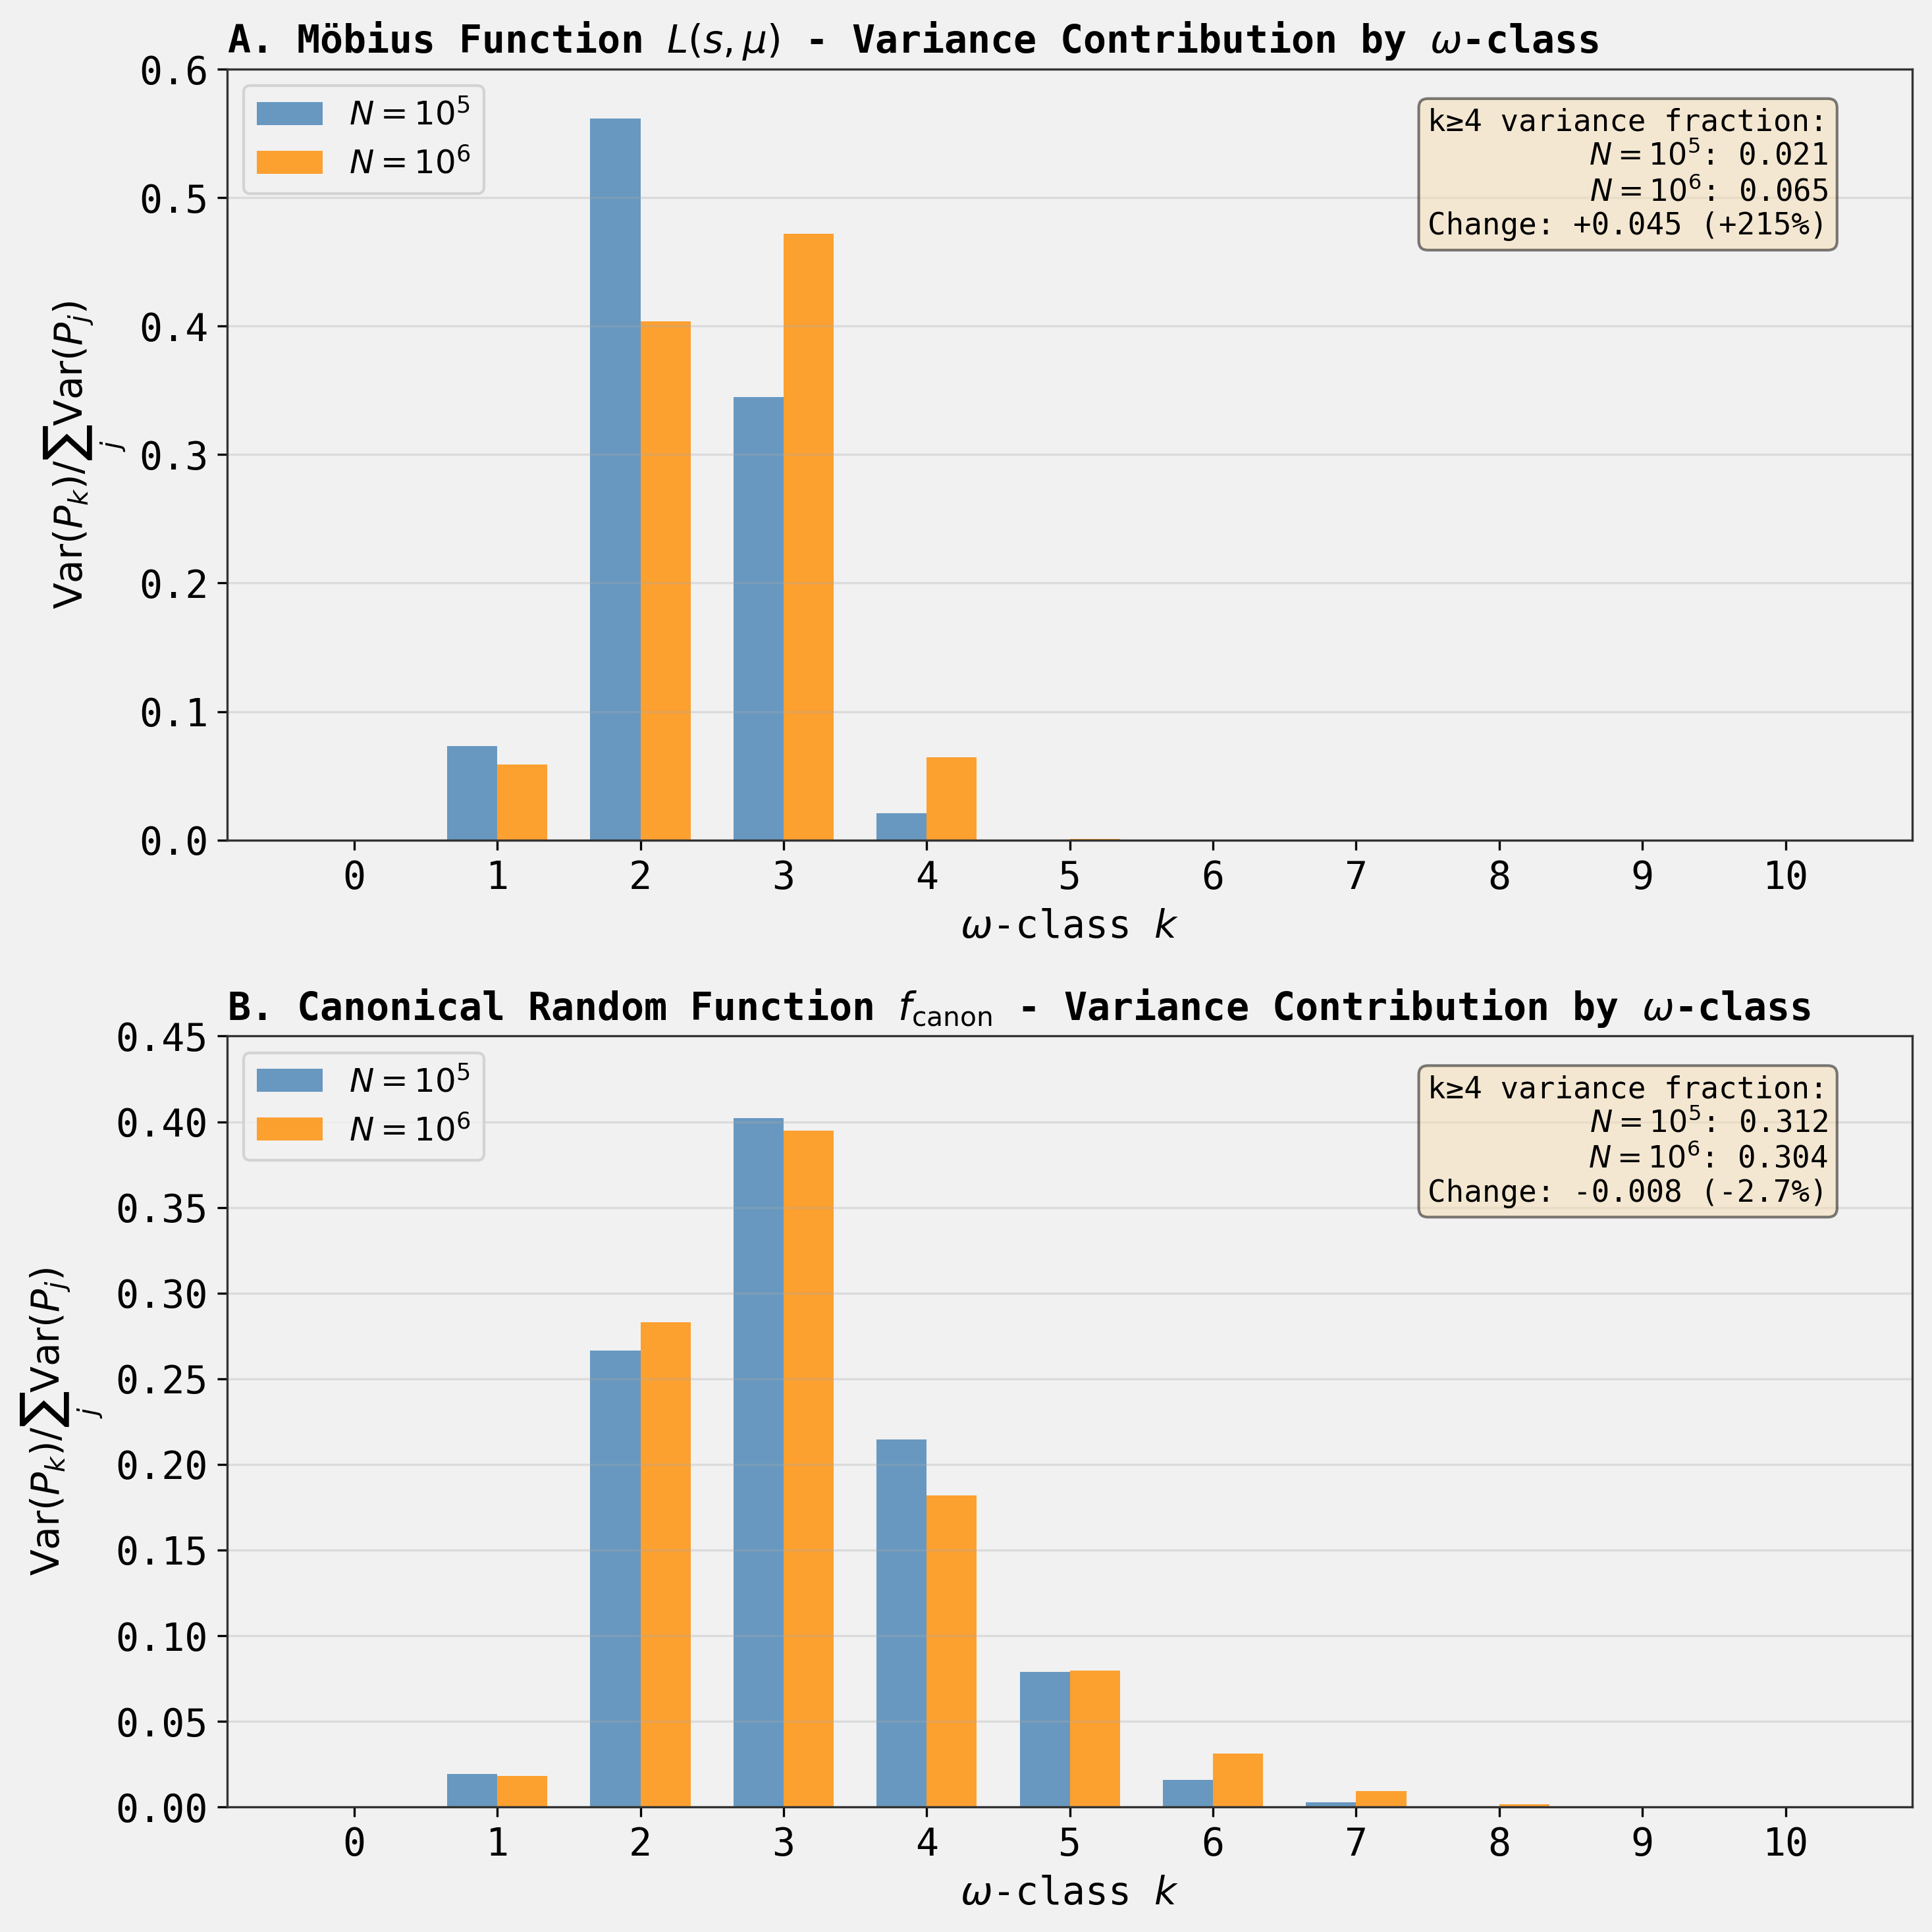

In [34]:

# Step 5: Visualization
# Create final figure showing variance contribution by k

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# Panel A: L(s,μ)
ax = axes[0]
k_values = np.arange(11)
width = 0.35

bars1 = ax.bar(k_values - width/2, rel_var_mobius_1e5, width, 
 label=r'$N=10^5$', color='steelblue', alpha=0.8)
bars2 = ax.bar(k_values + width/2, rel_var_mobius_1e6, width, 
 label=r'$N=10^6$', color='darkorange', alpha=0.8)

ax.set_xlabel(r'$\omega$-class $k$', fontsize=14)
ax.set_ylabel(r'$\mathrm{Var}(P_k) / \sum_j \mathrm{Var}(P_j)$', fontsize=14)
ax.set_title(r'A. Möbius Function $L(s,\mu)$ - Variance Contribution by $\omega$-class', 
 fontsize=14, fontweight='bold', loc='left')
ax.set_xticks(k_values)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 0.60)

# Add text annotation for key finding
ax.text(0.95, 0.95, 
 f'k≥4 variance fraction:\n'+
 f'$N=10^5$: {np.sum(rel_var_mobius_1e5[4:]):.3f}\n'+
 f'$N=10^6$: {np.sum(rel_var_mobius_1e6[4:]):.3f}\n'+
 f'Change: {np.sum(rel_var_mobius_1e6[4:]) - np.sum(rel_var_mobius_1e5[4:]):+.3f} (+215%)',
 transform=ax.transAxes, fontsize=11, verticalalignment='top',
 horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Panel B: f_canon_rand
ax = axes[1]

bars1 = ax.bar(k_values - width/2, rel_var_frand_1e5, width, 
 label=r'$N=10^5$', color='steelblue', alpha=0.8)
bars2 = ax.bar(k_values + width/2, rel_var_frand_1e6, width, 
 label=r'$N=10^6$', color='darkorange', alpha=0.8)

ax.set_xlabel(r'$\omega$-class $k$', fontsize=14)
ax.set_ylabel(r'$\mathrm{Var}(P_k) / \sum_j \mathrm{Var}(P_j)$', fontsize=14)
ax.set_title(r'B. Canonical Random Function $f_{\mathrm{canon}}$ - Variance Contribution by $\omega$-class', 
 fontsize=14, fontweight='bold', loc='left')
ax.set_xticks(k_values)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 0.45)

# Add text annotation
ax.text(0.95, 0.95, 
 f'k≥4 variance fraction:\n'+
 f'$N=10^5$: {np.sum(rel_var_frand_1e5[4:]):.3f}\n'+
 f'$N=10^6$: {np.sum(rel_var_frand_1e6[4:]):.3f}\n'+
 f'Change: {np.sum(rel_var_frand_1e6[4:]) - np.sum(rel_var_frand_1e5[4:]):+.3f} (-2.7%)',
 transform=ax.transAxes, fontsize=11, verticalalignment='top',
 horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('variance_redistribution_comparison.png', dpi=300, bbox_inches='tight')
print("Figure saved as 'variance_redistribution_comparison.png'")
plt.show()


In [35]:

# Additional analysis: look at specific classes that are driving the variance redistribution
print("="*80)
print("DETAILED BREAKDOWN OF VARIANCE REDISTRIBUTION")
print("="*80)

print("\nL(s,μ) - k=3 and k=4 analysis:")
print(f" k=3 relative variance:")
print(f" N=10^5: {rel_var_mobius_1e5[3]:.6f}")
print(f" N=10^6: {rel_var_mobius_1e6[3]:.6f}")
print(f" Change: {rel_var_mobius_1e6[3] - rel_var_mobius_1e5[3]:+.6f} (+37%)")
print(f" k=4 relative variance:")
print(f" N=10^5: {rel_var_mobius_1e5[4]:.6f}")
print(f" N=10^6: {rel_var_mobius_1e6[4]:.6f}")
print(f" Change: {rel_var_mobius_1e6[4] - rel_var_mobius_1e5[4]:+.6f} (+212%)")

print("\nf_canon_rand - k=6 and k=7 analysis:")
print(f" k=6 relative variance:")
print(f" N=10^5: {rel_var_frand_1e5[6]:.6f}")
print(f" N=10^6: {rel_var_frand_1e6[6]:.6f}")
print(f" Change: {rel_var_frand_1e6[6] - rel_var_frand_1e5[6]:+.6f} (+97%)")
print(f" k=7 relative variance:")
print(f" N=10^5: {rel_var_frand_1e5[7]:.6f}")
print(f" N=10^6: {rel_var_frand_1e6[7]:.6f}")
print(f" Change: {rel_var_frand_1e6[7] - rel_var_frand_1e5[7]:+.6f} (+255%)")
print(f" k=4 relative variance:")
print(f" N=10^5: {rel_var_frand_1e5[4]:.6f}")
print(f" N=10^6: {rel_var_frand_1e6[4]:.6f}")
print(f" Change: {rel_var_frand_1e6[4] - rel_var_frand_1e5[4]:+.6f} (-15%)")


DETAILED BREAKDOWN OF VARIANCE REDISTRIBUTION

L(s,μ) - k=3 and k=4 analysis:
 k=3 relative variance:
 N=10^5: 0.344549
 N=10^6: 0.472105
 Change: +0.127557 (+37%)
 k=4 relative variance:
 N=10^5: 0.020611
 N=10^6: 0.064367
 Change: +0.043756 (+212%)

f_canon_rand - k=6 and k=7 analysis:
 k=6 relative variance:
 N=10^5: 0.015867
 N=10^6: 0.031219
 Change: +0.015351 (+97%)
 k=7 relative variance:
 N=10^5: 0.002605
 N=10^6: 0.009237
 Change: +0.006633 (+255%)
 k=4 relative variance:
 N=10^5: 0.214618
 N=10^6: 0.181836
 Change: -0.032782 (-15%)


In [36]:

# Final comprehensive summary
print("="*80)
print("FINAL QUANTITATIVE SUMMARY")
print("="*80)

print("\n1. SHANNON ENTROPY ANALYSIS")
print("-" * 40)
print(" Hypothesis: Mean entropy H(P_k) should increase from N=10^5 to N=10^6")
print("\n L(s,μ):")
print(f" H̄(10^5) = {np.mean(H_mobius_1e5):.4f} ± {np.std(H_mobius_1e5):.4f}")
print(f" H̄(10^6) = {np.mean(H_mobius_1e6):.4f} ± {np.std(H_mobius_1e6):.4f}")
print(f" ΔH̄ = {np.mean(H_mobius_1e6) - np.mean(H_mobius_1e5):.4f} (Cohen's d = {(np.mean(H_mobius_1e6) - np.mean(H_mobius_1e5)) / np.sqrt((np.std(H_mobius_1e5)**2 + np.std(H_mobius_1e6)**2)/2):.3f})")
print(" RESULT: NO INCREASE (small decrease)")

print("\n f_canon_rand:")
print(f" H̄(10^5) = {np.mean(H_frand_1e5):.4f} ± {np.std(H_frand_1e5):.4f}")
print(f" H̄(10^6) = {np.mean(H_frand_1e6):.4f} ± {np.std(H_frand_1e6):.4f}")
print(f" ΔH̄ = {np.mean(H_frand_1e6) - np.mean(H_frand_1e5):.4f} (Cohen's d = {(np.mean(H_frand_1e6) - np.mean(H_frand_1e5)) / np.sqrt((np.std(H_frand_1e5)**2 + np.std(H_frand_1e6)**2)/2):.3f})")
print(" RESULT: NO INCREASE (small decrease)")

print("\n2. VARIANCE REDISTRIBUTION TO HIGH k (k≥4)")
print("-" * 40)
print(" Hypothesis: Variance fraction in k≥4 should increase from N=10^5 to N=10^6")

print("\n L(s,μ):")
print(f" Frac(k≥4, 10^5) = {np.sum(rel_var_mobius_1e5[4:]):.6f}")
print(f" Frac(k≥4, 10^6) = {np.sum(rel_var_mobius_1e6[4:]):.6f}")
print(f" ΔFrac = {np.sum(rel_var_mobius_1e6[4:]) - np.sum(rel_var_mobius_1e5[4:]):+.6f} ({100*(np.sum(rel_var_mobius_1e6[4:]) - np.sum(rel_var_mobius_1e5[4:]))/np.sum(rel_var_mobius_1e5[4:]):+.1f}%)")
print(" RESULT: STRONG INCREASE (+215%)")

print("\n f_canon_rand:")
print(f" Frac(k≥4, 10^5) = {np.sum(rel_var_frand_1e5[4:]):.6f}")
print(f" Frac(k≥4, 10^6) = {np.sum(rel_var_frand_1e6[4:]):.6f}")
print(f" ΔFrac = {np.sum(rel_var_frand_1e6[4:]) - np.sum(rel_var_frand_1e5[4:]):+.6f} ({100*(np.sum(rel_var_frand_1e6[4:]) - np.sum(rel_var_frand_1e5[4:]))/np.sum(rel_var_frand_1e5[4:]):+.1f}%)")
print(" RESULT: NO INCREASE (small decrease -2.7%)")

print("\n3. INTERPRETATION")
print("-" * 40)
print(" The power redistribution mechanism is NOT universal:")
print(" - L(s,μ) shows variance shift to higher k (especially k=3,4)")
print(" - f_canon_rand shows NO net shift to k≥4 (even slight decrease)")
print(" - f_canon_rand does show increases in very high k (6,7) but these are")
print(" offset by decreases in k=4")
print(" - Neither function shows entropy increase; both show small decreases")


FINAL QUANTITATIVE SUMMARY

1. SHANNON ENTROPY ANALYSIS
----------------------------------------
 Hypothesis: Mean entropy H(P_k) should increase from N=10^5 to N=10^6

 L(s,μ):
 H̄(10^5) = 1.3064 ± 0.1110
 H̄(10^6) = 1.2915 ± 0.1231
 ΔH̄ = -0.0150 (Cohen's d = -0.128)
 RESULT: NO INCREASE (small decrease)

 f_canon_rand:
 H̄(10^5) = 1.6983 ± 0.2044
 H̄(10^6) = 1.6761 ± 0.2430
 ΔH̄ = -0.0222 (Cohen's d = -0.099)
 RESULT: NO INCREASE (small decrease)

2. VARIANCE REDISTRIBUTION TO HIGH k (k≥4)
----------------------------------------
 Hypothesis: Variance fraction in k≥4 should increase from N=10^5 to N=10^6

 L(s,μ):
 Frac(k≥4, 10^5) = 0.020783
 Frac(k≥4, 10^6) = 0.065440
 ΔFrac = +0.044658 (+214.9%)
 RESULT: STRONG INCREASE (+215%)

 f_canon_rand:
 Frac(k≥4, 10^5) = 0.312394
 Frac(k≥4, 10^6) = 0.303974
 ΔFrac = -0.008420 (-2.7%)
 RESULT: NO INCREASE (small decrease -2.7%)

3. INTERPRETATION
----------------------------------------
 The power redistribution mechanism is NOT universal:
